# Auditoria 1: inventario y metricas de etiquetas

Este notebook audita **las etiquetas que ya existen**. Solo lee `data/**/*.csv`, los sidecars `*.txt` y, cuando existe, `*.labels.txt`; no modifica datos ni genera etiquetas nuevas.

Cada grabacion tiene 20 segmentos consecutivos de unos 3 segundos. Para `knock_twice_left` y `knock_twice_right` se espera exactamente un evento por segmento, es decir, 20 por archivo. Para las demas acciones se esperan cero eventos.

> Importante: una coincidencia con `detect_second_tap_frame` solo demuestra consistencia con el autoetiquetador, porque este notebook ejecuta el mismo algoritmo. No demuestra que el pico represente un tap real. La validacion de verdad se hace visualmente en `02_visual_label_review.ipynb`.


## Metricas calculadas

- Cobertura: eventos esperados, eventos escritos, segmentos sin etiqueta y segmentos con etiquetas multiples.
- Integridad: clase izquierda/derecha esperada, frames dentro del archivo y dentro de un unico segmento, sidecar denso valido.
- Consistencia automatica: diferencia entre el segundo pico guardado y el segundo pico recalculado, intervalo entre picos y fuerza robusta de ambos picos.
- Controles negativos: cuantos segmentos de acciones negativas tambien contienen un par de picos que el algoritmo aceptaria. Esto revela donde el heuristico puede confundirse con vibraciones o movimientos.
- Geometria de la captura: frecuencia de muestreo, duracion y posicion relativa de los eventos dentro de cada segmento.


In [12]:
from __future__ import annotations

import csv
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# This lets the notebook run from the repository root or from notebooks/.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'tap_recognition').is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'tap_recognition').is_dir(), 'Run this notebook from the repository root or notebooks/.'
sys.path.insert(0, str(REPO_ROOT))

from tap_recognition.dataset import (
    load_full_recording,
    load_segment_row_bounds,
    load_trigger_events,
)
from tap_recognition.labels import (
    CLASS_LEFT,
    CLASS_RIGHT,
    acc_energy_delta,
    detect_second_tap_frame,
)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})
POSITIVE_ACTION_TO_CLASS = {
    'knock_twice_left': CLASS_LEFT,
    'knock_twice_right': CLASS_RIGHT,
}
CLASS_NAME = {0: 'none', CLASS_LEFT: 'left', CLASS_RIGHT: 'right'}
# Keep this aligned with the --strict-spike-window-ms values used for imuStrict files.
STRICT_SPIKE_WINDOW_MS = (2000.0, 2850.0)
DATA_PATHS = sorted((REPO_ROOT / 'data').glob('*/*.csv'))
print(f'Repository: {REPO_ROOT}')
print(f'CSV recordings found: {len(DATA_PATHS)}')
print('If pandas is missing in this environment, install it in .venv before running this notebook.')


Repository: /home/aprohack/desktop/work/tap-project/project/tapRecognitionRui/TapRecognition
CSV recordings found: 90
If pandas is missing in this environment, install it in .venv before running this notebook.


## Construir las tablas de auditoria

`file_df` tiene una fila por grabacion. `segment_df` tiene una fila por segmento y es la tabla principal para investigar casos concretos. Las columnas que empiezan por `auto_` se recalculan con el mismo detector de picos que genero los sidecars; deben usarse para detectar incoherencias internas, no como evidencia independiente de que una etiqueta sea correcta.


In [13]:
def read_csv_metadata(csv_path: Path) -> tuple[dict[str, str], np.ndarray]:
    with csv_path.open(encoding='utf-8-sig', newline='') as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        raise ValueError(f'No rows in {csv_path}')
    timestamps_ms = np.asarray([float(row['timestamp_ms']) for row in rows])
    return rows[0], timestamps_ms


def segment_index_for_frame(bounds: list[tuple[int, int]], frame: int) -> int | None:
    matches = [i for i, (start, end) in enumerate(bounds, start=1) if start <= frame < end]
    return matches[0] if len(matches) == 1 else None


def robust_z(value: float, values: np.ndarray) -> float:
    median = float(np.median(values))
    mad = float(np.median(np.abs(values - median)))
    scale = 1.4826 * mad
    return 0.0 if scale < 1e-8 else (value - median) / scale


def dense_label_diagnostics(csv_path: Path, events: list[tuple[int, int]]) -> dict[str, object]:
    dense_path = csv_path.with_name(csv_path.stem + '.labels.txt')
    result: dict[str, object] = {
        'dense_exists': dense_path.exists(),
        'dense_rows': np.nan,
        'dense_read_error': '',
        'dense_probability_min': np.nan,
        'dense_probability_max': np.nan,
        'dense_max_sum_error': np.nan,
        'dense_event_peak_min': np.nan,
    }
    if not dense_path.exists():
        return result
    try:
        dense = np.loadtxt(dense_path, delimiter=',', skiprows=1, ndmin=2)
        result['dense_rows'] = len(dense)
        if dense.ndim != 2 or dense.shape[1] != 3:
            result['dense_read_error'] = f'Expected [N, 3], got {dense.shape}'
            return result
        result['dense_probability_min'] = float(dense.min())
        result['dense_probability_max'] = float(dense.max())
        result['dense_max_sum_error'] = float(np.max(np.abs(dense.sum(axis=1) - 1.0)))
        event_peaks = [dense[frame, class_id] for frame, class_id in events if 0 <= frame < len(dense)]
        if event_peaks:
            result['dense_event_peak_min'] = float(np.min(event_peaks))
    except Exception as exc:
        result['dense_read_error'] = repr(exc)
    return result


def audit_recording(csv_path: Path) -> tuple[dict[str, object], list[dict[str, object]]]:
    metadata, timestamps_ms = read_csv_metadata(csv_path)
    imu, sample_rate = load_full_recording(csv_path)
    bounds = load_segment_row_bounds(csv_path)
    events = load_trigger_events(csv_path.with_suffix('.txt'))
    action = metadata.get('action_label', '')
    expected_class = POSITIVE_ACTION_TO_CLASS.get(action)
    expected_events = len(bounds) if expected_class is not None else 0
    energy = acc_energy_delta(imu[:, :3])
    strict_window = (
        tuple(value / 1000.0 for value in STRICT_SPIKE_WINDOW_MS)
        if csv_path.name.startswith('imuStrict') else None
    )
    event_segments = [segment_index_for_frame(bounds, frame) for frame, _ in events]
    dense = dense_label_diagnostics(csv_path, events)

    file_row: dict[str, object] = {
        'split': csv_path.parent.name,
        'file': csv_path.name,
        'path': str(csv_path.relative_to(REPO_ROOT)),
        'user': metadata.get('user_name', ''),
        'action': action,
        'is_positive_action': expected_class is not None,
        'expected_class': CLASS_NAME.get(expected_class, 'none'),
        'rows': len(imu),
        'segments': len(bounds),
        'sample_rate_hz': sample_rate,
        'duration_sec': (timestamps_ms[-1] - timestamps_ms[0]) / 1000.0,
        'expected_events': expected_events,
        'sparse_events': len(events),
        'events_in_a_segment': sum(seg is not None for seg in event_segments),
        'events_outside_segments': sum(seg is None for seg in event_segments),
        'wrong_event_class': sum(class_id != expected_class for _, class_id in events) if expected_class else len(events),
        'event_count_delta': len(events) - expected_events,
        **dense,
    }

    segment_rows: list[dict[str, object]] = []
    for segment_index, (start, end) in enumerate(bounds, start=1):
        local_events = [(frame, class_id) for frame, class_id in events if start <= frame < end]
        unrestricted_pair = detect_second_tap_frame(
            imu[start:end, :3],
            imu[start:end, 3:],
            sample_rate=sample_rate,
        )
        pair = detect_second_tap_frame(
            imu[start:end, :3],
            imu[start:end, 3:],
            sample_rate=sample_rate,
            first_tap_after_sec=strict_window[0] if strict_window else None,
            second_tap_before_sec=strict_window[1] if strict_window else None,
        )
        local_energy = energy[start:end]
        auto_n1 = start + pair[0] if pair is not None else None
        auto_n2 = start + pair[1] if pair is not None else None
        unrestricted_n1 = start + unrestricted_pair[0] if unrestricted_pair is not None else None
        unrestricted_n2 = start + unrestricted_pair[1] if unrestricted_pair is not None else None
        label_frame = local_events[0][0] if len(local_events) == 1 else None
        label_class = local_events[0][1] if len(local_events) == 1 else None
        if len(local_events) == 0:
            label_state = 'missing' if expected_class is not None else 'empty'
        elif len(local_events) == 1:
            label_state = 'one_label'
        else:
            label_state = 'multiple_labels'

        n1_strength = robust_z(float(energy[auto_n1]), local_energy) if auto_n1 is not None else np.nan
        n2_strength = robust_z(float(energy[auto_n2]), local_energy) if auto_n2 is not None else np.nan
        segment_rows.append({
            'split': csv_path.parent.name,
            'file': csv_path.name,
            'path': str(csv_path.relative_to(REPO_ROOT)),
            'user': metadata.get('user_name', ''),
            'action': action,
            'is_positive_action': expected_class is not None,
            'expected_class': CLASS_NAME.get(expected_class, 'none'),
            'segment_index': segment_index,
            'start_frame': start,
            'end_frame': end,
            'segment_rows': end - start,
            'segment_duration_sec': (timestamps_ms[end - 1] - timestamps_ms[start]) / 1000.0,
            'label_state': label_state,
            'label_count': len(local_events),
            'label_frame': label_frame,
            'label_class': CLASS_NAME.get(label_class, 'none') if label_class is not None else None,
            'label_class_matches_action': label_class == expected_class if label_class is not None and expected_class else len(local_events) == 0,
            'label_position_sec': (label_frame - start) / sample_rate if label_frame is not None else np.nan,
            'auto_pair_found': pair is not None,
            'auto_search_window_ms': STRICT_SPIKE_WINDOW_MS if strict_window else None,
            'auto_unrestricted_pair_found': unrestricted_pair is not None,
            'auto_pair_blocked_by_window': pair is None and unrestricted_pair is not None and strict_window is not None,
            'auto_n1_frame': auto_n1,
            'auto_n2_frame': auto_n2,
            'auto_unrestricted_n1_frame': unrestricted_n1,
            'auto_unrestricted_n2_frame': unrestricted_n2,
            'auto_n1_position_sec': (auto_n1 - start) / sample_rate if auto_n1 is not None else np.nan,
            'auto_n2_position_sec': (auto_n2 - start) / sample_rate if auto_n2 is not None else np.nan,
            'auto_delta_t_sec': (auto_n2 - auto_n1) / sample_rate if auto_n2 is not None else np.nan,
            'auto_n1_robust_z': n1_strength,
            'auto_n2_robust_z': n2_strength,
            'label_minus_auto_n2_frames': label_frame - auto_n2 if label_frame is not None and auto_n2 is not None else np.nan,
        })
    return file_row, segment_rows


file_rows, segment_rows = [], []
for csv_path in DATA_PATHS:
    file_row, rows = audit_recording(csv_path)
    file_rows.append(file_row)
    segment_rows.extend(rows)

file_df = pd.DataFrame(file_rows).sort_values(['split', 'action', 'file']).reset_index(drop=True)
segment_df = pd.DataFrame(segment_rows).sort_values(['split', 'action', 'file', 'segment_index']).reset_index(drop=True)
print(f'Built file_df with {len(file_df)} rows and segment_df with {len(segment_df)} rows.')


Built file_df with 90 rows and segment_df with 1800 rows.


## Resumen de cobertura e integridad

La primera tabla debe mostrar 20 segmentos y 20 eventos para cada archivo positivo, y 20 segmentos con 0 eventos para cada archivo negativo. Una fila anomala es una prioridad para revisar visualmente. La segunda tabla comprueba que cada segmento positivo tenga exactamente una etiqueta y que los negativos no la tengan.


In [14]:
coverage_by_action = (
    file_df.groupby(['split', 'action'], as_index=False)
    .agg(
        files=('file', 'size'),
        segments=('segments', 'sum'),
        expected_events=('expected_events', 'sum'),
        sparse_events=('sparse_events', 'sum'),
        event_count_delta=('event_count_delta', 'sum'),
        wrong_event_class=('wrong_event_class', 'sum'),
        outside_segments=('events_outside_segments', 'sum'),
    )
)
display(coverage_by_action)

segment_coverage = (
    segment_df.groupby(['split', 'action', 'label_state'], as_index=False)
    .size()
    .pivot(index=['split', 'action'], columns='label_state', values='size')
    .fillna(0)
    .astype(int)
)
display(segment_coverage)

file_anomalies = file_df.loc[
    (file_df['event_count_delta'] != 0)
    | (file_df['wrong_event_class'] != 0)
    | (file_df['events_outside_segments'] != 0)
    | (file_df['segments'] != 20),
    ['path', 'action', 'segments', 'expected_events', 'sparse_events', 'event_count_delta', 'wrong_event_class', 'events_outside_segments'],
]
if file_anomalies.empty:
    print('No count, class, segment-boundary, or segment-count anomalies found.')
else:
    display(file_anomalies)

segment_anomalies = segment_df.loc[
    ((segment_df['is_positive_action']) & (segment_df['label_state'] != 'one_label'))
    | ((~segment_df['is_positive_action']) & (segment_df['label_state'] != 'empty'))
]
if segment_anomalies.empty:
    print('Every positive segment has one sparse label and every negative segment is empty.')
else:
    display(segment_anomalies)


,split,action,files,segments,expected_events,sparse_events,event_count_delta,wrong_event_class,outside_segments
0,train_data,adjust_grip,4,80,0,0,0,0,0
1,train_data,arbitrary,2,40,0,0,0,0,0
2,train_data,knock_once,4,80,0,0,0,0,0
3,train_data,knock_twice_left,18,360,360,356,-4,0,0
4,train_data,knock_twice_right,19,380,380,376,-4,0,0
5,train_data,pick_place,2,40,0,0,0,0,0
6,train_data,shake_phone,9,180,0,0,0,0,0
7,train_data,switch_hand,2,40,0,0,0,0,0
8,valid_data,adjust_grip,1,20,0,0,0,0,0
9,valid_data,arbitrary,1,20,0,0,0,0,0


label_state                   empty  missing  one_label
split      action                                      
train_data adjust_grip           80        0          0
           arbitrary             40        0          0
           knock_once            80        0          0
           knock_twice_left       0        4        356
           knock_twice_right      0        4        376
           pick_place            40        0          0
           shake_phone          180        0          0
           switch_hand           40        0          0
valid_data adjust_grip           20        0          0
           arbitrary             20        0          0
           knock_once            40        0          0
           knock_twice_left       0        2        158
           knock_twice_right      0        0        180
           pick_place            20        0          0
           shake_phone          120        0          0
           switch_hand           40        0          0

,path,action,segments,expected_events,sparse_events,event_count_delta,wrong_event_class,events_outside_segments
22,data/train_data/imu_Miguel_knock_twice_left_20...,knock_twice_left,20,20,18,-2,0,0
23,data/train_data/imu_Miguel_knock_twice_left_20...,knock_twice_left,20,20,18,-2,0,0
41,data/train_data/imu_Miguel_knock_twice_right_2...,knock_twice_right,20,20,17,-3,0,0
42,data/train_data/imu_Miguel_knock_twice_right_2...,knock_twice_right,20,20,19,-1,0,0
71,data/valid_data/imu_Miguel_knock_twice_left_20...,knock_twice_left,20,20,18,-2,0,0


,split,file,path,user,action,is_positive_action,expected_class,segment_index,start_frame,end_frame,...,auto_n1_frame,auto_n2_frame,auto_unrestricted_n1_frame,auto_unrestricted_n2_frame,auto_n1_position_sec,auto_n2_position_sec,auto_delta_t_sec,auto_n1_robust_z,auto_n2_robust_z,label_minus_auto_n2_frames
441,train_data,imu_Miguel_knock_twice_left_20260925_105524.csv,data/train_data/imu_Miguel_knock_twice_left_20...,Miguel,knock_twice_left,True,left,2,301,603,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
451,train_data,imu_Miguel_knock_twice_left_20260925_105524.csv,data/train_data/imu_Miguel_knock_twice_left_20...,Miguel,knock_twice_left,True,left,12,3327,3631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
465,train_data,imu_Miguel_knock_twice_left_20260925_152309.csv,data/train_data/imu_Miguel_knock_twice_left_20...,Miguel,knock_twice_left,True,left,6,1513,1817,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
466,train_data,imu_Miguel_knock_twice_left_20260925_152309.csv,data/train_data/imu_Miguel_knock_twice_left_20...,Miguel,knock_twice_left,True,left,7,1817,2121,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
823,train_data,imu_Miguel_knock_twice_right_20260925_105401.csv,data/train_data/imu_Miguel_knock_twice_right_2...,Miguel,knock_twice_right,True,right,4,907,1209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
828,train_data,imu_Miguel_knock_twice_right_20260925_105401.csv,data/train_data/imu_Miguel_knock_twice_right_2...,Miguel,knock_twice_right,True,right,9,2419,2723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,train_data,imu_Miguel_knock_twice_right_20260925_105401.csv,data/train_data/imu_Miguel_knock_twice_right_2...,Miguel,knock_twice_right,True,right,18,5145,5450,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
858,train_data,imu_Miguel_knock_twice_right_20260925_152103.csv,data/train_data/imu_Miguel_knock_twice_right_2...,Miguel,knock_twice_right,True,right,19,5452,5755,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1424,valid_data,imu_Miguel_knock_twice_left_20260925_152423.csv,data/valid_data/imu_Miguel_knock_twice_left_20...,Miguel,knock_twice_left,True,left,5,1208,1512,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1426,valid_data,imu_Miguel_knock_twice_left_20260925_152423.csv,data/valid_data/imu_Miguel_knock_twice_left_20...,Miguel,knock_twice_left,True,left,7,1815,2117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
dense_columns = [
    'path', 'rows', 'dense_exists', 'dense_rows', 'dense_read_error',
    'dense_probability_min', 'dense_probability_max',
    'dense_max_sum_error', 'dense_event_peak_min',
]
display(file_df[dense_columns])

print('Dense-label expectations for positive files:')
print('- dense_rows equals CSV rows')
print('- every probability is in [0, 1]')
print('- dense_max_sum_error is close to zero')
print('- dense_event_peak_min is close to one at every sparse event frame')
print('The training dataset currently reads the sparse .txt sidecar and regenerates dense labels; this check identifies disagreement but does not make .labels.txt the training source.')


,path,rows,dense_exists,dense_rows,dense_read_error,dense_probability_min,dense_probability_max,dense_max_sum_error,dense_event_peak_min
0,data/train_data/imu_Miguel_adjust_grip_2026092...,6061,False,NaN,,NaN,NaN,NaN,NaN
1,data/train_data/imu_Miguel_adjust_grip_2026092...,6062,False,NaN,,NaN,NaN,NaN,NaN
2,data/train_data/imu_Miguel_adjust_grip_2026092...,6066,False,NaN,,NaN,NaN,NaN,NaN
3,data/train_data/imu_Miguel_adjust_grip_2026092...,6064,False,NaN,,NaN,NaN,NaN,NaN
4,data/train_data/imu_Miguel_arbitrary_20260921_...,6055,False,NaN,,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
85,data/valid_data/imu_ZR_shake_phone_20260904_10...,6053,False,NaN,,NaN,NaN,NaN,NaN
86,data/valid_data/imu_ZR_shake_phone_20260908_17...,6054,False,NaN,,NaN,NaN,NaN,NaN
87,data/valid_data/imu_ZR_shake_phone_20260909_09...,6064,False,NaN,,NaN,NaN,NaN,NaN
88,data/valid_data/imu_Miguel_switch_hand_2026092...,6059,False,NaN,,NaN,NaN,NaN,NaN


Dense-label expectations for positive files:
- dense_rows equals CSV rows
- every probability is in [0, 1]
- dense_max_sum_error is close to zero
- dense_event_peak_min is close to one at every sparse event frame
The training dataset currently reads the sparse .txt sidecar and regenerates dense labels; this check identifies disagreement but does not make .labels.txt the training source.


## Consistencia con el algoritmo automatico

`label_minus_auto_n2_frames == 0` es lo esperable si los sidecars fueron generados por el codigo actual. Si no es cero, alguien modifico etiquetas o cambio el algoritmo. Aun cuando sea cero, la etiqueta puede ser incorrecta: el mismo heuristico puede elegir el pico equivocado.


In [16]:
positive_segments = segment_df[segment_df['is_positive_action']].copy()
# Build a scalar table directly: DataFrame.agg named aggregation changes across pandas releases.
consistency = pd.DataFrame.from_dict(
    {
        'expected_positive_segments': len(positive_segments),
        'labels_present': int(positive_segments['label_frame'].notna().sum()),
        'auto_pairs_found': int(positive_segments['auto_pair_found'].sum()),
        'exact_auto_n2_match': int((positive_segments['label_minus_auto_n2_frames'] == 0).sum()),
        'n2_mismatch': int((
            positive_segments['label_minus_auto_n2_frames'].notna()
            & (positive_segments['label_minus_auto_n2_frames'] != 0)
        ).sum()),
    },
    orient='index',
    columns=['value'],
)
display(consistency)

mismatches = positive_segments.loc[
    positive_segments['label_minus_auto_n2_frames'].notna()
    & (positive_segments['label_minus_auto_n2_frames'] != 0),
    ['path', 'segment_index', 'label_frame', 'auto_n1_frame', 'auto_n2_frame', 'label_minus_auto_n2_frames'],
]
if mismatches.empty:
    print('All present positive labels match the currently recomputed auto-label peak exactly.')
else:
    display(mismatches)

interval_violations = positive_segments.loc[
    positive_segments['auto_pair_found']
    & ~positive_segments['auto_delta_t_sec'].between(0.12, 0.45),
    ['path', 'segment_index', 'auto_delta_t_sec'],
]
print(f'Positive auto pairs outside [0.12, 0.45] s: {len(interval_violations)}')
display(interval_violations)


,value
expected_positive_segments,1080
labels_present,1070
auto_pairs_found,1056
exact_auto_n2_match,1056
n2_mismatch,0


All present positive labels match the currently recomputed auto-label peak exactly.
Positive auto pairs outside [0.12, 0.45] s: 0


,path,segment_index,auto_delta_t_sec


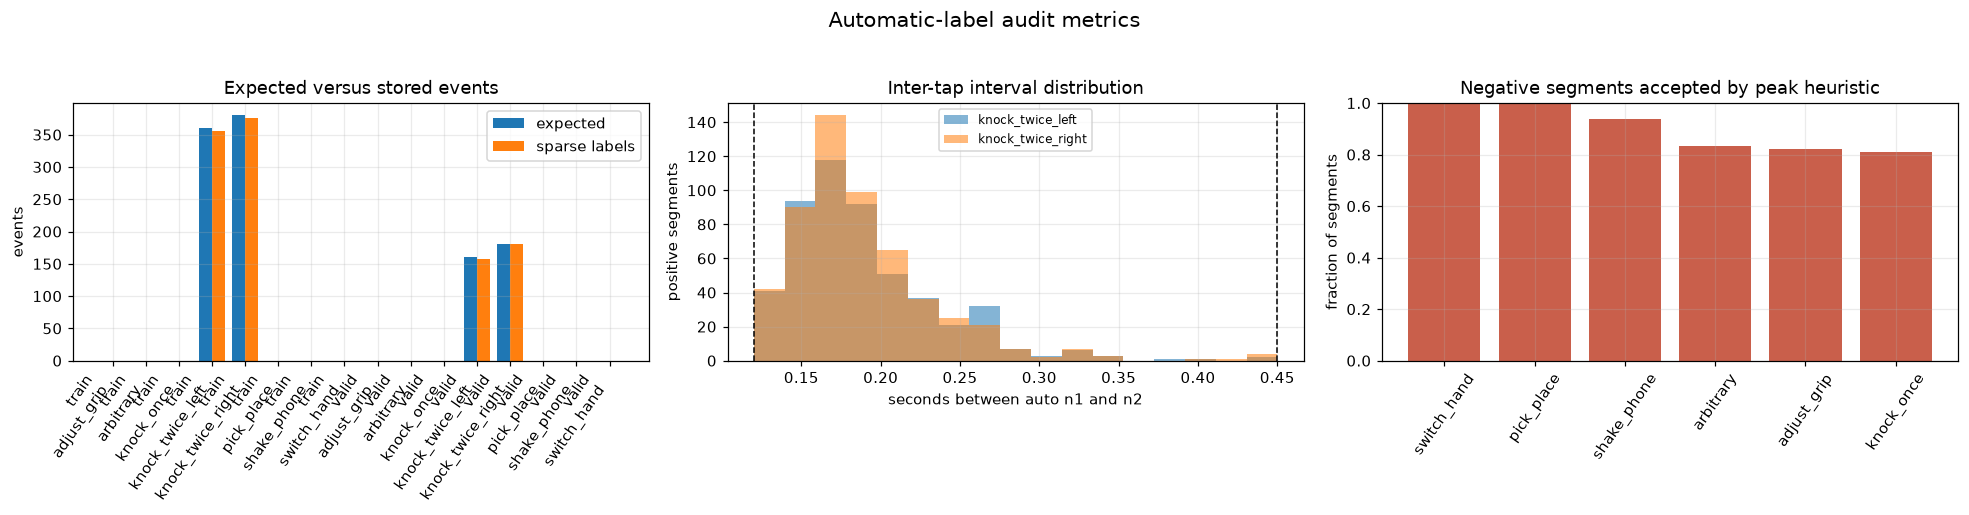

The third plot is a hard-negative signal, not a false-positive rate for the trained neural model.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

action_order = sorted(file_df['action'].unique())
by_action = coverage_by_action.set_index(['split', 'action'])
x_labels, expected, detected = [], [], []
for split, action in by_action.index:
    row = by_action.loc[(split, action)]
    x_labels.append(f"{split.replace('_data', '')}\n{action}")
    expected.append(row['expected_events'])
    detected.append(row['sparse_events'])
x = np.arange(len(x_labels))
axes[0].bar(x - 0.2, expected, width=0.4, label='expected')
axes[0].bar(x + 0.2, detected, width=0.4, label='sparse labels')
axes[0].set_xticks(x, x_labels, rotation=55, ha='right')
axes[0].set_ylabel('events')
axes[0].set_title('Expected versus stored events')
axes[0].legend()

for action, group in positive_segments.groupby('action'):
    axes[1].hist(group['auto_delta_t_sec'].dropna(), bins=np.linspace(0.12, 0.45, 18), alpha=0.55, label=action)
axes[1].axvline(0.12, color='black', linestyle='--', linewidth=1)
axes[1].axvline(0.45, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('seconds between auto n1 and n2')
axes[1].set_ylabel('positive segments')
axes[1].set_title('Inter-tap interval distribution')
axes[1].legend(fontsize=8)

negative_segments = segment_df[~segment_df['is_positive_action']].copy()
negative_rates = negative_segments.groupby('action')['auto_pair_found'].mean().sort_values(ascending=False)
axes[2].bar(negative_rates.index, negative_rates.values, color='#c95f4b')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('fraction of segments')
axes[2].set_title('Negative segments accepted by peak heuristic')
axes[2].tick_params(axis='x', rotation=55)

fig.suptitle('Automatic-label audit metrics', y=1.03, fontsize=14)
fig.tight_layout()
plt.show()

print('The third plot is a hard-negative signal, not a false-positive rate for the trained neural model.')


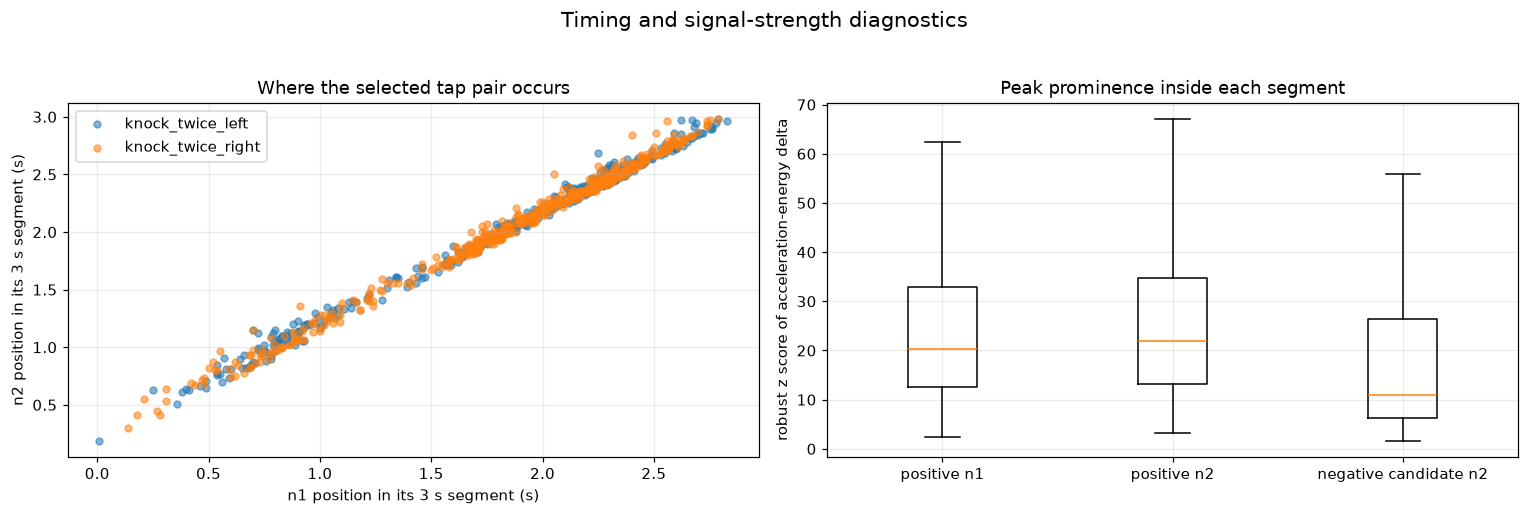

A high robust z score means a peak is large relative to that segment. It does not prove it was caused by a tap.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for action, group in positive_segments.groupby('action'):
    axes[0].scatter(
        group['auto_n1_position_sec'],
        group['auto_n2_position_sec'],
        alpha=0.55,
        s=20,
        label=action,
    )
axes[0].set_xlabel('n1 position in its 3 s segment (s)')
axes[0].set_ylabel('n2 position in its 3 s segment (s)')
axes[0].set_title('Where the selected tap pair occurs')
axes[0].legend()

strength_data = [
    positive_segments['auto_n1_robust_z'].dropna(),
    positive_segments['auto_n2_robust_z'].dropna(),
    negative_segments.loc[negative_segments['auto_pair_found'], 'auto_n2_robust_z'].dropna(),
]
axes[1].boxplot(strength_data, showfliers=False)
axes[1].set_xticks([1, 2, 3], ['positive n1', 'positive n2', 'negative candidate n2'])
axes[1].set_ylabel('robust z score of acceleration-energy delta')
axes[1].set_title('Peak prominence inside each segment')

fig.suptitle('Timing and signal-strength diagnostics', y=1.03, fontsize=14)
fig.tight_layout()
plt.show()

print('A high robust z score means a peak is large relative to that segment. It does not prove it was caused by a tap.')


## Priorizar la revision visual

Los siguientes controles producen dos listas de trabajo. La primera contiene positivos con pares debiles, raros o inconsistentes. La segunda contiene movimientos negativos en los que el heuristico encuentra una pareja aparentemente valida; son los mejores candidatos para estudiar confusiones. Copia una ruta y un `segment_index` en el segundo notebook.


In [19]:
positive_priority = (
    positive_segments.assign(
        weakest_peak=lambda frame: frame[['auto_n1_robust_z', 'auto_n2_robust_z']].min(axis=1),
        n2_offset=lambda frame: frame['label_minus_auto_n2_frames'].abs(),
    )
    .sort_values(['auto_pair_found', 'label_state', 'weakest_peak'], ascending=[True, True, True])
    [[
        'path', 'segment_index', 'label_state', 'label_frame', 'auto_search_window_ms',
        'auto_pair_blocked_by_window', 'auto_n1_frame', 'auto_n2_frame',
        'auto_unrestricted_n1_frame', 'auto_unrestricted_n2_frame', 'auto_delta_t_sec',
        'auto_n1_robust_z', 'auto_n2_robust_z', 'label_minus_auto_n2_frames',
    ]]
)
display(positive_priority.head(15))

negative_priority = (
    negative_segments[negative_segments['auto_pair_found']]
    .assign(weakest_peak=lambda frame: frame[['auto_n1_robust_z', 'auto_n2_robust_z']].min(axis=1))
    .sort_values('weakest_peak', ascending=False)
    [[
        'path', 'action', 'segment_index', 'auto_n1_frame', 'auto_n2_frame',
        'auto_delta_t_sec', 'auto_n1_robust_z', 'auto_n2_robust_z', 'weakest_peak',
    ]]
)
display(negative_priority.head(15))


,path,segment_index,label_state,label_frame,auto_search_window_ms,auto_pair_blocked_by_window,auto_n1_frame,auto_n2_frame,auto_unrestricted_n1_frame,auto_unrestricted_n2_frame,auto_delta_t_sec,auto_n1_robust_z,auto_n2_robust_z,label_minus_auto_n2_frames
441,data/train_data/imu_Miguel_knock_twice_left_20...,2,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
451,data/train_data/imu_Miguel_knock_twice_left_20...,12,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
465,data/train_data/imu_Miguel_knock_twice_left_20...,6,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
466,data/train_data/imu_Miguel_knock_twice_left_20...,7,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
823,data/train_data/imu_Miguel_knock_twice_right_2...,4,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
828,data/train_data/imu_Miguel_knock_twice_right_2...,9,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,data/train_data/imu_Miguel_knock_twice_right_2...,18,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
858,data/train_data/imu_Miguel_knock_twice_right_2...,19,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1424,data/valid_data/imu_Miguel_knock_twice_left_20...,5,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1426,data/valid_data/imu_Miguel_knock_twice_left_20...,7,missing,NaN,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,path,action,segment_index,auto_n1_frame,auto_n2_frame,auto_delta_t_sec,auto_n1_robust_z,auto_n2_robust_z,weakest_peak
1641,data/valid_data/imu_Miguel_shake_phone_2026092...,shake_phone,2,408.0,422.0,0.14,425.768892,261.753038,261.753038
1738,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,19,5507.0,5529.0,0.22,249.158604,295.499338,249.158604
1733,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,14,3997.0,4010.0,0.13,200.211441,204.764997,200.211441
1739,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,20,5811.0,5824.0,0.13,193.818193,218.716364,193.818193
1727,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,8,2170.0,2182.0,0.12,186.713466,189.972331,186.713466
1719,data/valid_data/imu_ZR_shake_phone_20260904_10...,shake_phone,20,5864.0,5897.0,0.33,190.282171,184.341749,184.341749
1049,data/train_data/imu_Miguel_shake_phone_2026092...,shake_phone,10,2832.0,2846.0,0.14,257.475787,179.870982,179.870982
1731,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,12,3394.0,3411.0,0.17,185.432886,157.719103,157.719103
1717,data/valid_data/imu_ZR_shake_phone_20260904_10...,shake_phone,18,5226.0,5244.0,0.18,152.659244,270.298272,152.659244
976,data/train_data/imu_Miguel_pick_place_20260924...,pick_place,17,5017.0,5032.0,0.15,146.727317,193.431376,146.727317


In [22]:
positive_priority.head(10).to_numpy()

array([['data/train_data/imu_Miguel_knock_twice_left_20260925_105524.csv',
        2, 'missing', nan, None, False, nan, nan, nan, nan, nan, nan,
        nan, nan],
       ['data/train_data/imu_Miguel_knock_twice_left_20260925_105524.csv',
        12, 'missing', nan, None, False, nan, nan, nan, nan, nan, nan,
        nan, nan],
       ['data/train_data/imu_Miguel_knock_twice_left_20260925_152309.csv',
        6, 'missing', nan, None, False, nan, nan, nan, nan, nan, nan,
        nan, nan],
       ['data/train_data/imu_Miguel_knock_twice_left_20260925_152309.csv',
        7, 'missing', nan, None, False, nan, nan, nan, nan, nan, nan,
        nan, nan],
       ['data/train_data/imu_Miguel_knock_twice_right_20260925_105401.csv',
        4, 'missing', nan, None, False, nan, nan, nan, nan, nan, nan,
        nan, nan],
       ['data/train_data/imu_Miguel_knock_twice_right_20260925_105401.csv',
        9, 'missing', nan, None, False, nan, nan, nan, nan, nan, nan,
        nan, nan],
       ['data

In [21]:
negative_priority.head(10).to_numpy()

array([['data/valid_data/imu_Miguel_shake_phone_20260921_172915.csv',
        'shake_phone', 2, 408.0, 422.0, 0.14, 425.7688923679277,
        261.7530384355283, 261.7530384355283],
       ['data/valid_data/imu_ZR_shake_phone_20260908_175719.csv',
        'shake_phone', 19, 5507.0, 5529.0, 0.22, 249.15860378658965,
        295.4993375603828, 249.15860378658965],
       ['data/valid_data/imu_ZR_shake_phone_20260908_175719.csv',
        'shake_phone', 14, 3997.0, 4010.0, 0.13, 200.21144059537087,
        204.76499669793375, 200.21144059537087],
       ['data/valid_data/imu_ZR_shake_phone_20260908_175719.csv',
        'shake_phone', 20, 5811.0, 5824.0, 0.13, 193.81819255402146,
        218.71636350683724, 193.81819255402146],
       ['data/valid_data/imu_ZR_shake_phone_20260908_175719.csv',
        'shake_phone', 8, 2170.0, 2182.0, 0.12, 186.71346623766541,
        189.9723305535295, 186.71346623766541],
       ['data/valid_data/imu_ZR_shake_phone_20260904_102826.csv',
        'shake_phon

## Interpretacion y limites

- `20 / 20` por archivo positivo es una condicion necesaria, pero no suficiente. El algoritmo puede seleccionar un pico incorrecto en los 20 segmentos.
- Los negativos con `auto_pair_found=True` no estan mal etiquetados: siguen siendo negativos por el protocolo de captura. Sirven para revelar que patrones de movimiento pueden parecer un doble toque al heuristico.
- La fuerza robusta compara un pico solo contra el mismo segmento. No debe compararse directamente entre usuarios si sus sensores, orientacion o fuerza de tap son diferentes.
- Las etiquetas de archivo provienen del protocolo de recoleccion; la revision humana debe verificar que el comportamiento esperado ocurrio realmente y que n1/n2 apuntan a la pareja fisica correcta.
- Continuar en `02_visual_label_review.ipynb` para revisar la forma de onda y registrar `correct`, `uncertain` o `incorrect` para cada segmento positivo.
